In [21]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
xx=load_breast_cancer()
xx.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [22]:
xx.DESCR

'.. _breast_cancer_dataset:\n\nBreast cancer Wisconsin (diagnostic) dataset\n--------------------------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 569\n\n:Number of Attributes: 30 numeric, predictive attributes and the class\n\n:Attribute Information:\n    - radius (mean of distances from center to points on the perimeter)\n    - texture (standard deviation of gray-scale values)\n    - perimeter\n    - area\n    - smoothness (local variation in radius lengths)\n    - compactness (perimeter^2 / area - 1.0)\n    - concavity (severity of concave portions of the contour)\n    - concave points (number of concave portions of the contour)\n    - symmetry\n    - fractal dimension ("coastline approximation" - 1)\n\n    The mean, standard error, and "worst" or largest (mean of the three\n    worst/largest values) of these features were computed for each image,\n    resulting in 30 features.  For instance, field 0 is Mean Radius, field\n    10 is Radius SE, field 

In [23]:
x=pd.DataFrame(data=xx.data,columns=xx.feature_names)
y=xx.target
x.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [24]:
x.columns=x.columns.str.replace(' ','_')
x.columns

Index(['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
       'mean_smoothness', 'mean_compactness', 'mean_concavity',
       'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension',
       'radius_error', 'texture_error', 'perimeter_error', 'area_error',
       'smoothness_error', 'compactness_error', 'concavity_error',
       'concave_points_error', 'symmetry_error', 'fractal_dimension_error',
       'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area',
       'worst_smoothness', 'worst_compactness', 'worst_concavity',
       'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension'],
      dtype='object')

0.9473684210526315
7 16
[0.         0.00218083 0.0029304  0.00431133 0.00559513 0.00743872
 0.0086638  0.01291987 0.01438561 0.02404453 0.02442056 0.0306549
 0.3228506 ] [0.         0.00872332 0.01165373 0.01596506 0.02156019 0.0289989
 0.0376627  0.05058258 0.06496819 0.08901272 0.11343328 0.14408818
 0.46693878]


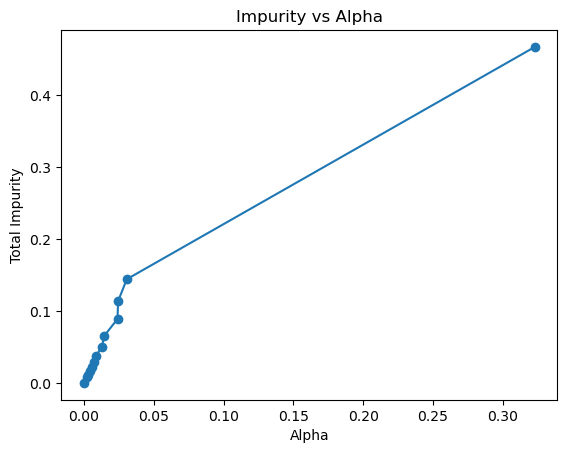

In [25]:
from sklearn.model_selection import train_test_split,cross_val_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier(random_state=42)
clf.fit(x_train,y_train)
print(clf.score(x_test,y_test))
print(clf.get_depth(),clf.get_n_leaves())
path=clf.cost_complexity_pruning_path(x_train,y_train)
alphas, impurity=path.ccp_alphas, path.impurities
print(alphas,impurity)
import matplotlib.pyplot as plt
plt.plot(alphas, impurity, marker='o')
plt.xlabel("Alpha")
plt.ylabel("Total Impurity")
plt.title("Impurity vs Alpha")
plt.show()

In [26]:
c=[]
y=[]

In [27]:
for i in alphas:
    clff=DecisionTreeClassifier(random_state=42,ccp_alpha=i)
    #clff.fit(x_train,y_train)
    #c.append(clff.fit(x_train,y_train))
    c.append(cross_val_score(clff,x_train,y_train,cv=5).mean())
    



In [28]:
bn=np.argmax(c)
print(bn)
best=alphas[bn]
print(best)

6
0.008663799968147794


In [29]:
cvb=DecisionTreeClassifier(random_state=42,ccp_alpha=best)
cvb.fit(x_train,y_train)
print(cvb.get_depth(),cvb.get_n_leaves())
print(cvb.score(x_test,y_test))

4 7
0.956140350877193
